#**Optimization in Logistic Regression,Multiclass Logistic Regression**

##**Agenda**
- **PART 1 — Recap: Logistic Regression & Probabilistic View**
- **PART 2 — Log Loss (Cost Function)**
- **PART 3 — Optimization with Gradient Descent**
- **PART 4 — Multiclass Classification Problem**
- **PART 5 — One-vs-Rest (OvR)**
- **PART 6 — Softmax (Multinomial Logistic Regression)**
- **PART 7 — OvR vs Softmax**
- **PART 8 — Practical ML Perspective**


#**PART 1 — Recap: Logistic Regression & Probabilistic View**

**Logistic Regression Refresher**

- Unlike Linear Regression:

  - Linear Regression → Predicts Values
  - Logistic Regression → Predicts Probabilities

**Logistic Function**

- The probability prediction is obtained using Sigmoid:

$$P(y=1∣x)=σ(z)=
\frac{1}{1+e^
{−z}}
$$
	​


**where:**

- $$z = wᵀx + b$$


**The sigmoid transforms any real number into:**

- [0,1]

making it a valid probability.


**Probabilistic Interpretation**

- Logistic Regression is fundamentally a:

  - Probabilistic Classification Model

- For every input:

 - x

it predicts:

- $$P(y=1|x)$$

rather than a hard label.

**Example**

- Email Spam Detection

$$P(Spam) = 0.95$$


**Interpretation:**

- 95% confidence email is spam.

**Why Probabilities Matter**

- Real-world systems need confidence estimates:

**Examples:**
- Medical diagnosis
- Fraud detection
- Credit risk scoring
- Recommendation systems

#**PART 2 — Log Loss (Cost Function)**

**Why We Need a Cost Function**

- Suppose our model predicts:

  - 0.9

for a positive example.

**Good prediction.**

- Suppose model predicts:

  - 0.01

for a positive example.

**Terrible prediction.**

- We need a mathematical mechanism to measure:

  - Prediction Quality

- This is called the:

  - Cost Function / Loss Function



**Why MSE Is NOT Used**

- Many beginners ask:

  - Why not simply use Mean Squared Error?

- For Linear Regression:

  - MSE works beautifully.

- For Logistic Regression:

  - MSE creates optimization problems.


**Problem 1: Non-Convex Optimization**

- Sigmoid + MSE produces:

   - Multiple local minima

Optimization becomes difficult.

**Problem 2: Slow Learning**

- Gradients become extremely small.

  - Training becomes inefficient.

**Problem 3: Poor Probabilistic Interpretation**

- MSE is not derived from probability theory.

Log Loss is.


**Binary Cross Entropy (Log Loss)**

- Logistic Regression uses:

  - Log Loss

- Also called:

  - Binary Cross Entropy


**Formula**

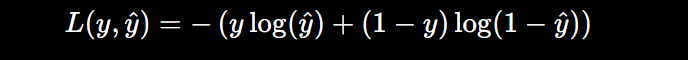

**Intuition**


**Case 1: Confident & Correct**
- Actual = 1
- Prediction = 0.99

**Loss ≈ 0**

- Excellent.

**Case 2: Uncertain**
- Actual = 1
- Prediction = 0.50

Moderate loss.

**Case 3: Confident & Wrong**
- Actual = 1
- Prediction = 0.001

Massive loss.


**Visual Intuition**

In [ ]:
print("""
Prediction Correctness ↑
Loss ↓

Prediction Wrongness ↑
Loss ↑↑↑
""")


Prediction Correctness ↑
Loss ↓

Prediction Wrongness ↑
Loss ↑↑↑



**Python Example**

In [2]:
import numpy as np

y_true = 1
y_pred = 0.95

loss = -(y_true*np.log(y_pred) +
        (1-y_true)*np.log(1-y_pred))

print(loss)

0.05129329438755058


**Probabilistic Foundation (MLE)**

- One of the most important interview concepts.


**Logistic Regression Assumes**

- Target variable follows:

  - Bernoulli Distribution

- For binary classification:

   - y ∈ {0,1}


**Maximum Likelihood Estimation**

- Instead of minimizing error directly:

  - We maximize:

     - Probability of observed data

**This process is called:**

- Maximum Likelihood Estimation (MLE)


**Key Insight**
Taking negative log of likelihood leads exactly to:
- Log Loss

#**PART 3 — Optimization with Gradient Descent**

**Why Optimization Is Needed**

We want to find:

 - Best w
 - Best b

that minimize loss.

Optimization searches for these parameters.


**Gradient Descent Overview**

- Gradient Descent is the engine that powers:

  - Logistic Regression
  - Neural Networks
  - Deep Learning
  - XGBoost optimization

**Core Idea**

- Imagine standing on a mountain.

**Goal:**

- Reach lowest valley.


**Parameter Update Rule**

- $$θ:=θ−η∇J(θ)$$

**where:**
- θ  = parameters
- η  = learning rate
- ∇J = gradient


**Python Example**

In [ ]:
import numpy as np

theta = np.array([1.0, 2.0])
gradient = np.array([0.1, 0.2])
lr = 0.01

theta = theta - lr * gradient

print(theta)

[0.999 1.998]


**Why Gradient Descent Works Well Here**

- Logistic Regression has:

  - Convex Loss Function

**Consequence**

- Convex loss implies:

  - Single Global Minimum



**Learning Rate Effects**

- Learning Rate controls step size.

  - Too Small

**Slow convergence**
- o-o-o-o-o-o-o
Too Larg e

**Divergence**
- o------o------o

Overshoots minimum.

**Optimal**
- Smooth convergence

  - o---o--o-o



**Python Example**

In [ ]:
learning_rate = 0.01

**Typical values:**

- 0.1
- 0.01
- 0.001




**Convergence Criteria**

- Training stops when:


**Condition 1**

- Gradient becomes tiny.

 - $$∇J ≈ 0$$

**Condition 2**

- Loss stops improving.

- Loss plateau


**Condition 3**

- Maximum iterations reached.

#**PART 4 — Multiclass Classification Problem**

**Binary Limitation**

- Standard Logistic Regression predicts:

  - Class 0
  - Class 1

only.

**Real-World Problems**

- Most problems involve:

  - More than 2 classes

**Examples** -

- Digit Recognition

- 0,1,2,3,4,5,6,7,8,9


**Product Classification**
- Electronics
- Fashion
- Books
- Sports
- News Categorization
- Politics
- Sports
- Business
- Technology

**Challenge**

- Need probabilities across:

  - K classes

instead of only 2.

#**PART 5 — One-vs-Rest (OvR)**

**OvR Strategy**

- OvR stands for:

   - One-vs-Rest


**Core Idea**

- For K classes:

  - Train:

   - K binary classifiers

**Example**

- Classes:

  - Cat
  - Dog
  - Bird

- Train:

  - Classifier 1:
    - Cat vs Rest

  - Classifier 2:
    - Dog vs Rest

  - Classifier 3:
    - Bird vs Rest

**Prediction Phase**

- Each classifier predicts:

  - $$P(y=k|x)$$


**Final class:**

- argmax(probabilities)

Choose highest probability.

**Python Example**

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    multi_class='ovr'
)

**Advantages**

- Simple
- Easy implementation
- Computationally efficient


**Limitations**

- Probabilities may not sum to 1.

**Example:**

- Cat  = 0.8
- Dog  = 0.7
- Bird = 0.6

Total = 2.1

Invalid probability distribution.





#**PART 6 — Softmax (Multinomial Logistic Regression)**

**Why OvR Is Not Enough**

- OvR treats each class independently.

Real-world classes should compete.

**Example:**

- Cat vs Dog vs Bird

These classes are related.

Softmax Function
 - Softmax converts scores into probabilities.

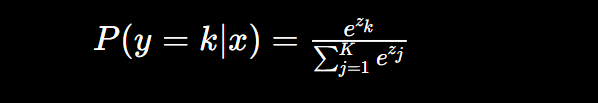

**Key Property**

- Probabilities always satisfy:

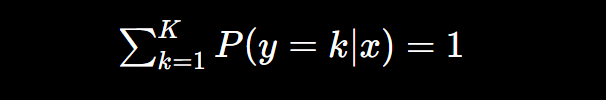

**Example**

**Raw Scores**
- Cat  = 2.0
- Dog  = 1.0
- Bird = 0.5

**After Softmax**
- Cat  = 0.63
- Dog  = 0.23
- Bird = 0.14


**Sum:**
- 1.00

**Why Softmax Is Better**

✔ Probabilities sum to 1

✔ Classes compete

✔ Single unified model

✔ Better probabilistic interpretation

**Python Example**

In [ ]:
import numpy as np

z = np.array([2.0, 1.0, 0.5])

softmax = np.exp(z) / np.sum(np.exp(z))

print(softmax)

[0.62853172 0.2312239  0.14024438]


**Cross Entropy Loss**

- Softmax uses:

  - Multiclass Cross Entropy

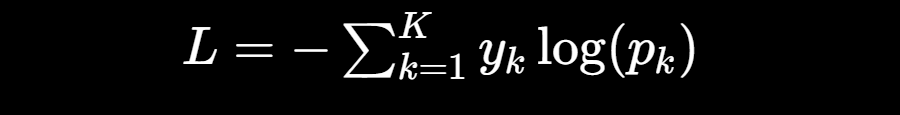

**Deep Learning Connection**

- The final layer of most neural networks:

In [ ]:
print("""
Dense Layer
       ↓
Softmax
       ↓
Cross Entropy Loss
""")


Dense Layer
       ↓
Softmax
       ↓
Cross Entropy Loss



#**PART 7 — OvR vs Softmax**

**Interview Comparison Table**
| Aspect               | OvR      | Softmax  |
| -------------------- | -------- | -------- |
| Models               | K        | 1        |
| Probability Sum      | ❌        | ✅        |
| Class Interaction    | ❌        | ✅        |
| Unified Optimization | ❌        | ✅        |
| Theoretical Elegance | Moderate | High     |
| Deep Learning Usage  | Rare     | Standard |


#**PART 8 — Practical ML Perspective**

**Logistic Regression in Production**

- Used for:

  - CTR Prediction
  - Fraud Detection
  - Risk Scoring
  - Ad Ranking
  - Customer Churn
  - Recommendation Systems


**Why Companies Love It**
- Fast
- Interpretable
- Probabilistic
- Easy to deploy
- Works surprisingly well

**Logistic Regression → Neural Networks**

- A neural network's final classification layer often reduces to:

Linear Transformation
+
Softmax

**which is essentially:**

- Multiclass Logistic Regression